In [6]:
import pandas
import numpy as np
from torchvision.datasets import ImageFolder
from torchvision import transforms
import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import cv2
from tqdm import tqdm
import json

In [5]:
dataset = ImageFolder(root='C:/Users/bogda/AILesson1/data/train_dataset_for_students', transform=transforms.ToTensor())
dataset[0]

(tensor([[[0.0431, 0.0314, 0.0706,  ..., 0.1333, 0.1373, 0.1529],
          [0.0196, 0.0392, 0.0667,  ..., 0.1529, 0.1529, 0.1490],
          [0.0392, 0.0471, 0.0745,  ..., 0.1373, 0.1451, 0.1412],
          ...,
          [0.6588, 0.6941, 0.6510,  ..., 0.6784, 0.6941, 0.6941],
          [0.6980, 0.7098, 0.6667,  ..., 0.7333, 0.7098, 0.6941],
          [0.6745, 0.6902, 0.6824,  ..., 0.7255, 0.7412, 0.7255]],
 
         [[0.0667, 0.0392, 0.0549,  ..., 0.0627, 0.0549, 0.0588],
          [0.0392, 0.0471, 0.0510,  ..., 0.0824, 0.0784, 0.0667],
          [0.0471, 0.0549, 0.0588,  ..., 0.0784, 0.0745, 0.0627],
          ...,
          [0.5608, 0.5961, 0.5529,  ..., 0.5843, 0.6000, 0.6000],
          [0.6039, 0.6157, 0.5725,  ..., 0.6392, 0.6157, 0.6000],
          [0.5804, 0.5961, 0.5882,  ..., 0.6314, 0.6471, 0.6314]],
 
         [[0.0510, 0.0275, 0.0431,  ..., 0.0471, 0.0353, 0.0431],
          [0.0235, 0.0353, 0.0471,  ..., 0.0667, 0.0627, 0.0549],
          [0.0431, 0.0431, 0.0549,  ...,

In [6]:
print(f"Количество изображений: {len(dataset)}")
print(f"Классы: {dataset.classes}")

img, label = dataset[0] 
print(f"Размер тензора картинки: {img.shape}")
print(f"ID класса: {label}")

Количество изображений: 880
Классы: ['img', 'labels']
Размер тензора картинки: torch.Size([3, 256, 256])
ID класса: 0


In [7]:
path_to_train = 'C:/Users/bogda/AILesson1/data/train_dataset_for_students/img/train' # укажите ваш путь
sizes = []

print("Сканирую изображения...")

for filename in os.listdir(path_to_train):
    if filename.lower().endswith('.jpg'):
        full_path = os.path.join(path_to_train, filename)
        try:
            with Image.open(full_path) as img:
                sizes.append(img.size)
        except Exception as e:
            print(f"Ошибка в файле {filename}: {e}")

size_counts = Counter(sizes)

if len(size_counts) == 1:
    print(f"✅ Все изображения одного размера: {list(size_counts.keys())[0]}")
else:
    print(f"❌ Найдено несколько размеров:")
    for size, count in size_counts.items():
        print(f"Размер {size}: {count} шт.")

Сканирую изображения...
✅ Все изображения одного размера: (256, 256)


In [6]:
def coco_to_png(json_path, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    coco = COCO(json_path)
    
    img_ids = coco.getImgIds()

    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        file_name = img_info['file_name']
        height = img_info['height']
        width = img_info['width']

        full_mask = np.zeros((height, width), dtype=np.uint8)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:
            category_id = ann['category_id']
            m = coco.annToMask(ann)
            full_mask = np.maximum(full_mask, m * category_id)

        mask_name = os.path.splitext(file_name)[0] + ".png"
        save_path = os.path.join(output_dir, mask_name)
        
        mask_img = Image.fromarray(full_mask)
        mask_img.save(save_path)
        
        print(f"Обработано: {file_name}")

json_file = 'C:/Users/bogda/AILesson1/data/annotations.json'
save_directory = 'C:/Users/bogda/AILesson1/data/masks'

coco_to_png(json_file, save_directory)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Обработано: 000000023731_404.jpg
Обработано: 000000028253_7169.jpg
Обработано: 000000121530_5761.jpg
Обработано: 000000247301_4455.jpg
Обработано: 000000275028_3168.jpg
Обработано: 000000275919_4499.jpg
Обработано: 000000419618_7033.jpg
Обработано: 000000574769_0.jpg


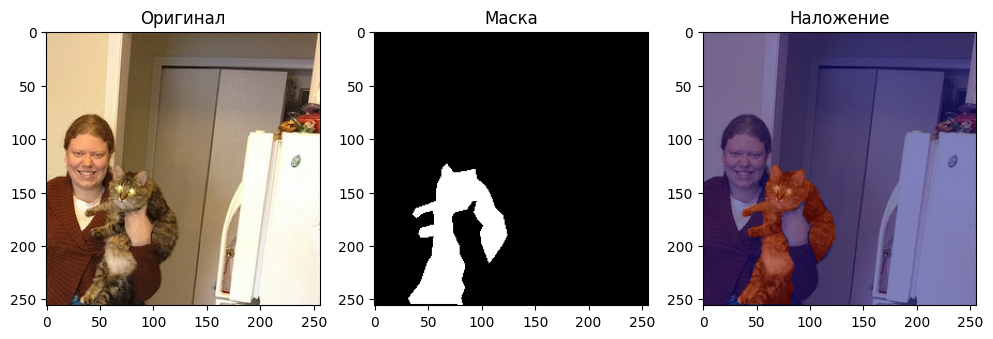

In [10]:
img_path = 'C:/Users/bogda/AILesson1/data/train_dataset_for_students/img/train/000000574769_0.jpg'
mask_path = 'C:/Users/bogda/AILesson1/data/masks/000000574769_0.png' # обычно маски в .png или .bmp

image = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Оригинал")
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.title("Маска")
plt.imshow(mask, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Наложение")
plt.imshow(image)
plt.imshow(mask, alpha=0.5, cmap='jet')
plt.show()

In [ ]:
MASK_DIR = 'C:/Users/bogda/AILesson1/data/train_dataset_for_students/labels/train' 
IMAGE_DIR = 'C:/Users/bogda/AILesson1/data/train_dataset_for_students/img/train'
OUTPUT_JSON = 'masksroboflow.json'
CATEGORIES = [
    {"id": 1, "name": "animal"},
]
def mask_to_polygons(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segmentation = []
    for contour in contours:
        if len(contour) < 3:
            continue
        segmentation.append(contour.flatten().tolist())
    return segmentation

def create_coco_json():
    coco_format = {"images": [], "annotations": [], "categories": CATEGORIES}
    annotation_id = 1
    image_id = 1

    mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.lower().endswith('.png')])
    
    print(f"Найдено файлов масок в папке: {len(mask_files)}")

    for filename in tqdm(mask_files, desc="Обработка"):
        mask_path = os.path.join(MASK_DIR, filename)
        
        # Читаем как есть
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            print(f"  [!] Ошибка: Не удалось прочитать файл {filename}")
            continue

        max_val = np.max(mask)
        if max_val == 0:
            print(f"  [?] Предупреждение: Маска {filename} полностью черная.")
        
        _, binary_mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

        height, width = mask.shape
        image_name = filename.replace('.png', '.jpg')
        
        coco_format["images"].append({
            "id": image_id,
            "width": width,
            "height": height,
            "file_name": image_name
        })

        polygons = mask_to_polygons(binary_mask)

        if not polygons and max_val > 0:
            print(f"  [!] Странно: В {filename} есть светлые пиксели, но контуры не найдены.")

        for poly in polygons:
            x, y, w, h = cv2.boundingRect(np.array(poly).reshape(-1, 2))
            area = cv2.contourArea(np.array(poly).reshape(-1, 2))
            
            if area < 1: 
                continue

            coco_format["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": 1,
                "segmentation": [poly],
                "area": area,
                "bbox": [int(x), int(y), int(w), int(h)],
                "iscrowd": 0
            })
            annotation_id += 1
        
        image_id += 1

    with open(OUTPUT_JSON, 'w') as f:
        json.dump(coco_format, f)
    
    print(f"\nГотово! Обработано изображений: {image_id - 1}")
    print(f"Всего создано аннотаций (объектов): {annotation_id - 1}")

if __name__ == "__main__":
    create_coco_json()

Найдено файлов масок в папке: 200


Обработка: 100%|██████████| 200/200 [00:00<00:00, 758.48it/s]



Готово! Обработано изображений: 200
Всего создано аннотаций (объектов): 218
